In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# Model Training
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer



warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/raw.csv')

In [3]:
df.head()

,gender,race,education,lunch,course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X = df.drop(columns=['math_score'])

In [6]:
X.head()

,gender,race,education,lunch,course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
print("Categories in 'Gender' Variable: ", end="  ")
print(df['gender'].unique())
print("Categories in 'race' Variable: ", end="  ")
print(df['race'].unique())
print("Categories in 'education' Variable: ", end="  ")
print(df['education'].unique())
print("Categories in 'lunch' Variable: ", end="  ")
print(df['lunch'].unique())
print("Categories in 'course' Variable: ", end="  ")
print(df['course'].unique())

Categories in 'Gender' Variable:   <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race' Variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'education' Variable:   <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' Variable:   <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'course' Variable:   <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [8]:
Y = df['math_score']

In [9]:
Y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

## Preprocessing

In [18]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

In [19]:
cat_features

Index(['gender', 'race', 'education', 'lunch', 'course'], dtype='str')

In [20]:

numeric_transformer = StandardScaler()
ohe_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", ohe_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

(1000, 7)

In [22]:
X = preprocessor.fit_transform(X)

In [23]:
X.shape

(1000, 19)

In [25]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

## Train / Test Split

In [26]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size= 0.2, random_state=42)

In [27]:
print(x_train.shape, x_test.shape)

(800, 19) (200, 19)


## Evaluate Model

In [29]:
def evaluate_model(true_value, predicted):
    mae = mean_absolute_error(true_value, predicted)
    mse = mean_squared_error(true_value, predicted)
    rmse = np.sqrt(mse)
    # rmse = np.sqrt(mean_squared_error(true_value, predicted))
    r2_square = r2_score(true_value, predicted)
    return mae, rmse, r2_square

In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbour Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
    "Catboost": CatBoostRegressor(),
    "AdaBoost": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):

    model = list(models.values())[i]
    model.fit(x_train, y_train)

    # Make Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluate train/test Dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("------- Model Performance for Training Dataset ----------")
    print("->> Root Mean Square Error: {:.4f}".format(model_train_rmse))
    print("->> Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("->> R2 Score: {:.4f}".format(model_train_r2))

    print("-------------------------------------")

    print("------- Model Performance for Testing Dataset ----------")
    print("->> Root Mean Square Error: {:.4f}".format(model_test_rmse))
    print("->> Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("->> R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("=" * 35)
    print('\n')

    

Linear Regression
------- Model Performance for Training Dataset ----------
->> Root Mean Square Error: 5.3231
->> Mean Absolute Error: 4.2667
->> R2 Score: 0.8743
-------------------------------------
------- Model Performance for Testing Dataset ----------
->> Root Mean Square Error: 5.3940
->> Mean Absolute Error: 4.2148
->> R2 Score: 0.8804


Lasso
------- Model Performance for Training Dataset ----------
->> Root Mean Square Error: 6.5938
->> Mean Absolute Error: 5.2063
->> R2 Score: 0.8071
-------------------------------------
------- Model Performance for Testing Dataset ----------
->> Root Mean Square Error: 6.5197
->> Mean Absolute Error: 5.1579
->> R2 Score: 0.8253


Ridge
------- Model Performance for Training Dataset ----------
->> Root Mean Square Error: 5.3233
->> Mean Absolute Error: 4.2650
->> R2 Score: 0.8743
-------------------------------------
------- Model Performance for Testing Dataset ----------
->> Root Mean Square Error: 5.3904
->> Mean Absolute Error: 4.2111


## Results

In [32]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Modle Name', 'R2 Score']).sort_values(by=['R2 Score'], ascending=False)

,Modle Name,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,Catboost,0.851632
5,Random Forest,0.850670
8,AdaBoost,0.844106
6,XGBoost,0.827797
1,Lasso,0.825320
3,K-Neighbour Regressor,0.783813
4,Decision Tree,0.727786


In [33]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


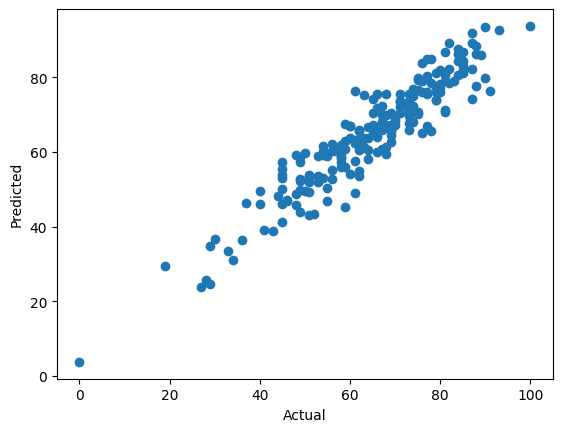

In [34]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

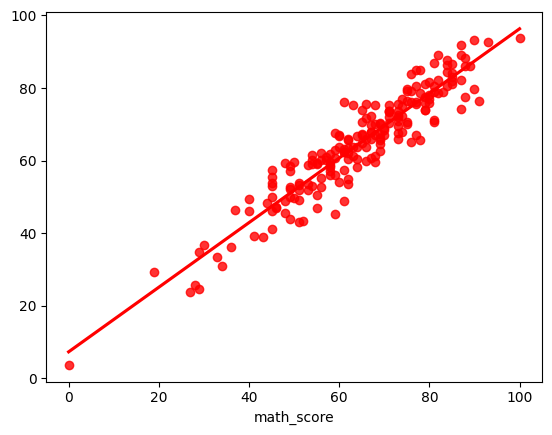

In [35]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [36]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
